# Hands-on Exercise for Module 1: Exploratory Data Analysis - Mansurbek Satarov

### 0.Importing important packages

In [226]:
# data loading and computing functionality
import pandas as pd
import numpy as np
import scipy as sp

# datasets in sklearn package
from sklearn import datasets
from sklearn.datasets import load_digits

# visualization packages
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm

#PCA, SVD, LDA
from sklearn.decomposition import PCA
from scipy.linalg import svd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


### 1. Loading data, determining samples, attributes, and types of attributes

Use Davis dataset avaialble at the url https://vincentarelbundock.github.io/Rdatasets/csv/carData/Davis.csv
    
Description of the data is provided at http://math.furman.edu/~dcs/courses/math47/R/library/car/html/Davis.html

Drop rows in the data set with missing values (NA), using dropna(inplace=True) function.

<span style="color:red">**Question 1a:** </span> Based on the data description, were the data points and what are the attributes in this data? <br>

<span style="color:green">Answer:</span> The data points are the individual people listed in each row of the dataset. The attributes are sex, weight, height, repwt (reported weight), and repht (reported height).

<span style="color:red">**Question 1b:** </span> Who are selected as subjects in the study? <br>

<span style="color:green">Answer:</span> The subjects were men and women engaged in regular exercise.

<span style="color:red">**Question 1c:** </span> How many data points are in this dataset? <br>

In [227]:
davis_df = pd.read_csv('https://vincentarelbundock.github.io/Rdatasets/csv/carData/Davis.csv')

In [228]:
# Original dataset shape
davis_df.shape

(200, 6)

In [229]:
davis_df.head()

,rownames,sex,weight,height,repwt,repht
0,1,M,77,182,77.0,180.0
1,2,F,58,161,51.0,159.0
2,3,F,53,161,54.0,158.0
3,4,M,68,177,70.0,175.0
4,5,F,59,157,59.0,155.0


In [230]:
davis_df.dropna(inplace=True);

In [231]:
# Dataset shape after dropping missing (NA) values
davis_df.shape

(181, 6)

 <span style="color:green">Answer:</span> After removing rows with missing (NA) values, the dataset contains 181 data points (observations of subjects).

<span style="color:red">**Question 1d:** </span> How many attributes are in this dataset? <br>

In [232]:
davis_df.dtypes

,0
rownames,int64
sex,object
weight,int64
height,int64
repwt,float64
repht,float64


 <span style="color:green">Answer:</span> There are 5 attributes in this dataset: sex, weight, height, reported weight (repwt), and reported height (repht).

<span style="color:red">**Question 1e:** </span> What type of attributes are present in the dataset? <br>
       

In [233]:
davis_df.dtypes

,0
rownames,int64
sex,object
weight,int64
height,int64
repwt,float64
repht,float64


 <span style="color:green">Answer:</span> 1 categorical attribute (sex) and 4 numerical (continuous) attributes.


### 2. Generating summary statistics

Use 'Davis' data. Do not include Unnamed (or rownames) attribute in this analysis.

In [234]:
davis_df.drop(columns=davis_df.columns[davis_df.columns.str.contains('unnamed', case=False)], inplace=True)

# Drop rownames column
davis_df.drop(columns=['rownames'], inplace=True)

davis_df.head()

,sex,weight,height,repwt,repht
0,M,77,182,77.0,180.0
1,F,58,161,51.0,159.0
2,F,53,161,54.0,158.0
3,M,68,177,70.0,175.0
4,F,59,157,59.0,155.0


<span style="color:red">**Question 2a:** </span> What are range of values the numeric attributes take? <br>
[Hint: Use exclude=object option in describe() function to ignore the attribute sex]

In [235]:
davis_df.describe(exclude=object)

,weight,height,repwt,repht
count,181.000000,181.000000,181.000000,181.000000
mean,66.303867,170.154696,65.679558,168.657459
std,15.340992,12.312069,13.834220,9.394668
min,39.000000,57.000000,41.000000,148.000000
25%,56.000000,164.000000,55.000000,161.000000
50%,63.000000,169.000000,63.000000,168.000000
75%,75.000000,178.000000,74.000000,175.000000
max,166.000000,197.000000,124.000000,200.000000


 <span style="color:green">Answer:</span>
- Weight: 39 to 166 kg

- Height: 57 to 197 cm

- Reported Weight (repwt): 41 to 124 kg

- Reported Height (repht): 148 to 200 cm

<span style="color:red">**Question 2b:** </span> What different values do categorical attributes take? <br>
[Hint: Use include=object option in describe() function to ignore the attribute sex]

In [236]:
davis_df.describe(include=object)

,sex
count,181
unique,2
top,F
freq,99


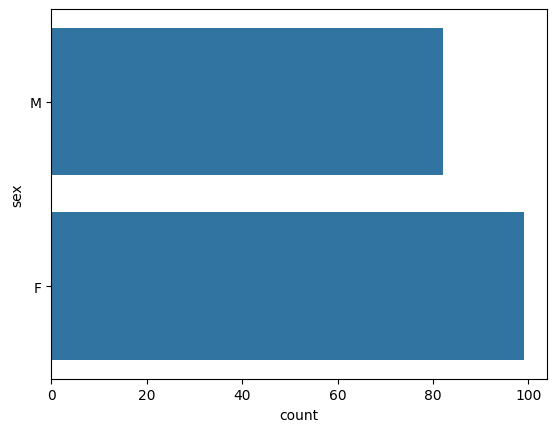

In [237]:
sns.countplot(davis_df['sex']);

 <span style="color:green">Answer:</span> The categorical attribute sex takes two different values: F (female) and M (male).

<span style="color:red">**Question 2c:** </span> What are the mean values for each of the numeric attributes? <br>

In [238]:
from pandas.api.types import is_numeric_dtype

for col in davis_df.columns:
    if is_numeric_dtype(davis_df[col]):
        print('%s:' % (col))
        print('\t Mean = %.2f' % davis_df[col].mean())


weight:
	 Mean = 66.30
height:
	 Mean = 170.15
repwt:
	 Mean = 65.68
repht:
	 Mean = 168.66


 <span style="color:green">Answer:</span> The mean values for the numeric attributes are:

* Weight: 66.30 kg

* Height: 170.15 cm

* Reported Weight (repwt): 65.68 kg

* Reported Height (repht): 168.66 cm

<span style="color:red">**Question 2d:** </span> What is the variance for each of the numeric attributes? <br>

In [239]:
from pandas.api.types import is_numeric_dtype

for col in davis_df.columns:
    if is_numeric_dtype(davis_df[col]):
        print('%s:' % (col))
        print('\t Variance = %.2f' % davis_df[col].var())

weight:
	 Variance = 235.35
height:
	 Variance = 151.59
repwt:
	 Variance = 191.39
repht:
	 Variance = 88.26


Answer:

The variance for the numeric attributes are:

* **Weight:** 235.35
* **Height:** 151.59
* **Reported Weight (repwt):** 191.39
* **Reported Height (repht):** 88.26


<span style="color:red">**Question 2e:** </span> Visually examine how the attribute 'weight' is distributed and comment if the distribution is more similar to a Gaussian distribution or to a uniform distribution?

/tmp/ipython-input-2156532287.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(davis_df['weight']);


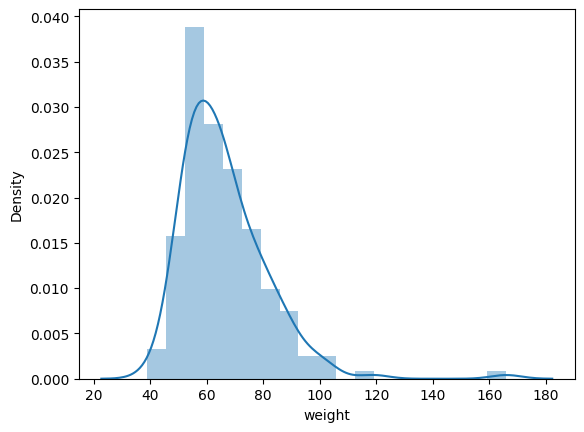

In [240]:
sns.distplot(davis_df['weight']);

 <span style="color:green">Answer:</span> The weight distribution appears approximately Gaussian (normal), as it is bell-shaped with most values clustered near the center and fewer at the extremes.

<span style="color:red">**Question 2f:** </span> Visually examine how the attribute 'height' is distributed and comment if the distribution is more similar to a Gaussian distribution or to a uniform distribution?

/tmp/ipython-input-2648581281.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(davis_df['height']);


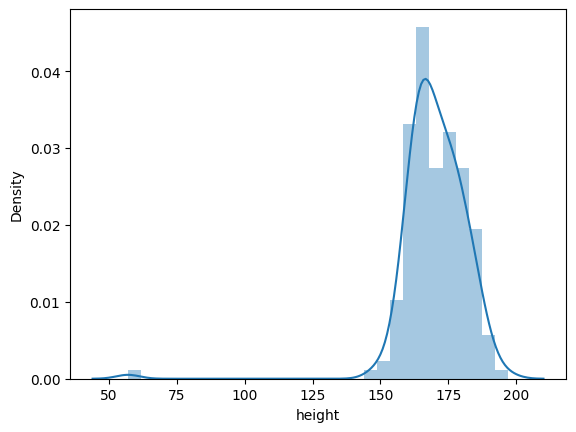

In [241]:
sns.distplot(davis_df['height']);

 <span style="color:green">Answer:</span> The height distribution appears approximately Gaussian (normal), as it is bell-shaped with most values clustered near the center and fewer at the extremes.

<span style="color:red">**Question 2g:** </span> Visually examine how the attribute 'repwt' is distributed and comment if the distribution is more similar to a Gaussian distribution or to a uniform distribution?

/tmp/ipython-input-2720062968.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(davis_df['repwt']);


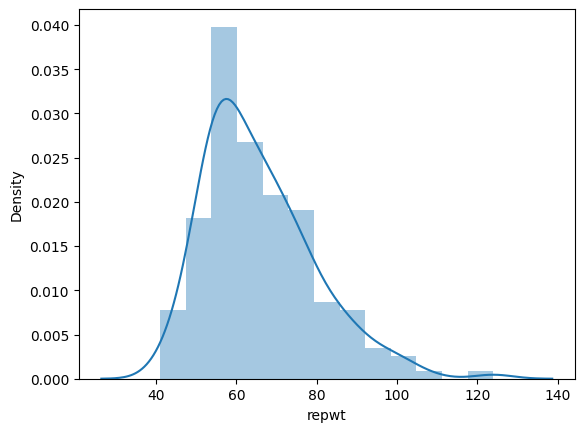

In [242]:
sns.distplot(davis_df['repwt']);

 <span style="color:green">Answer:</span> The distribution of repwt (reported weight) is more similar to a Gaussian (normal) distribution because it is roughly bell-shaped with most values centered around the mean.

<span style="color:red">**Question 2h:** </span> Visually examine how the attribute 'repht' is distributed and comment if the distribution is more similar to a Gaussian distribution or to a uniform distribution?

/tmp/ipython-input-859660446.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(davis_df['repht']);


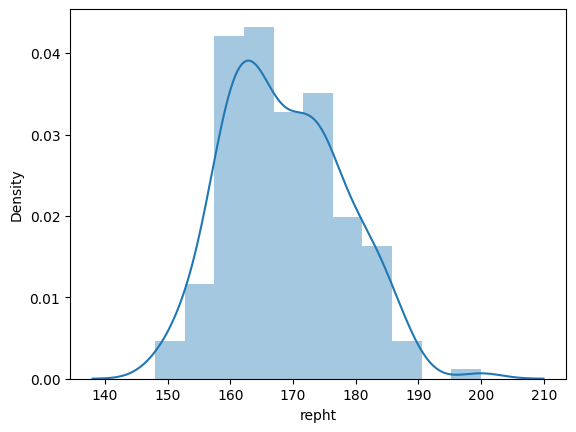

In [243]:
sns.distplot(davis_df['repht']);

 <span style="color:green">Answer:</span> The distribution of repht (reported height) is more similar to a Gaussian (normal) distribution because it is roughly bell-shaped with most values centered around the mean.

<span style="color:red">**Question 2i:** </span> Visually examine how the attribute 'sex' is distributed and comment if the distribution is more similar to a Gaussian distribution or to a uniform distribution?

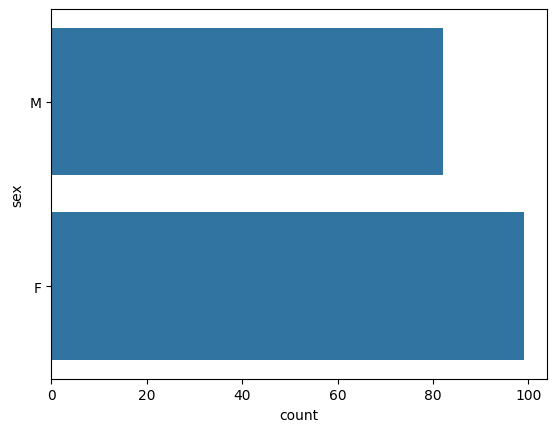

In [244]:
sns.countplot(davis_df['sex']);

 <span style="color:green">Answer:</span> The distribution of sex is more similar to a uniform distribution because the counts of males and females are relatively close to each other, rather than forming a bell-shaped pattern like a Gaussian distribution.

<span style="color:red">**Question 2j:** </span> Is it possible for attribute 'sex' to follow a Gaussian distribution? Support your answer with a rationale.

Answer: No, the attribute sex cannot follow a Gaussian distribution because it is a categorical variable with discrete values (male and female), while a Gaussian distribution applies only to continuous numerical data.

### 3. Geometric and Probabilistic view

<span style="color:brown">**Note:** </span> For this part, we will restrict to 'repwt' and 'repht' attributes in the davis dataset as we can only visualize 2D space.

In [249]:
davis_df_new = davis_df[['repwt','repht']]

In [250]:
davis_df_new.head()

,repwt,repht
0,77.0,180.0
1,51.0,159.0
2,54.0,158.0
3,70.0,175.0
4,59.0,155.0


<span style="color:red">**Question 3a:** </span> Show the Geometric view of this data 'davis_df_new' on a 2D space along with the mean.

<Axes: xlabel='repwt', ylabel='repht'>

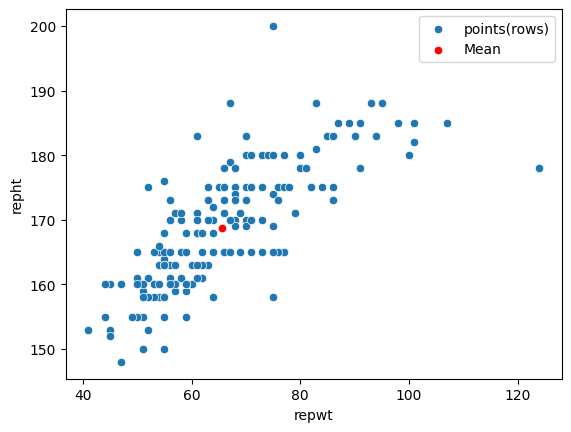

In [251]:
fig, ax = plt.subplots()
sns.scatterplot(x='repwt',y='repht',data=davis_df_new,ax=ax, label='points(rows)')
mu = np.mean(davis_df_new.values,0)
sns.scatterplot(x=[mu[0], mu[0]],y=[mu[1], mu[1]], color='r', label='Mean',ax=ax)

<span style="color:red">**Question 3b:** </span> From the geometric view, state your observations about the data and any relationships you observe between the attributes.

Answer: The scatter plot shows a positive relationship between reported weight (repwt) and reported height (repht), where height generally increases as weight increases. Most data points are clustered around the mean.

We will further normalize the magnitude of each row in the data (davis_df_new) to 1 and use the new dataframe davis_df_new_row_norm.

In [252]:
from sklearn.preprocessing import normalize
davis_df_new_row_norm = normalize(davis_df_new, axis=1, norm='l2')

In [253]:
davis_df_new_row_norm[1:10,:]

array([[0.30542755, 0.95221532],
       [0.32340548, 0.94626048],
       [0.37139068, 0.92847669],
       [0.35574458, 0.93458322],
       [0.41835989, 0.90828134],
       [0.42288547, 0.90618314],
       [0.37582461, 0.92669081],
       [0.37595091, 0.92663958],
       [0.35232976, 0.93587592]])

<span style="color:red">**Question 3c:** </span> Show the Geometric view of this new row normalized data on a 2D space along with the mean.

Text(0, 0.5, 'Normalized repht')

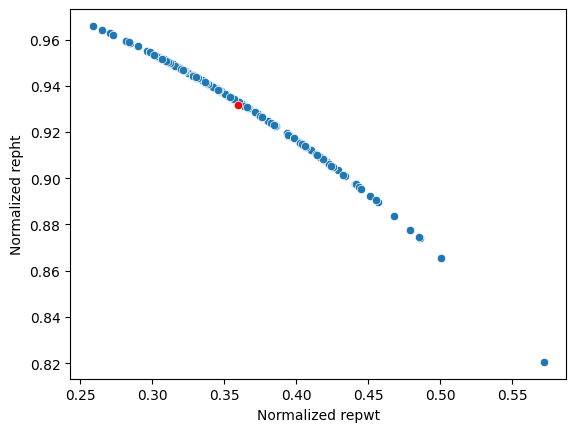

In [254]:
fig, ax = plt.subplots()
sns.scatterplot(x=davis_df_new_row_norm[:,0],y=davis_df_new_row_norm[:,1], ax=ax)
mu_norm = np.mean(davis_df_new_row_norm, axis=0)
sns.scatterplot(x=[mu_norm[0]],y=[mu_norm[1]], color='r',ax=ax)
ax.set_xlabel("Normalized repwt")
ax.set_ylabel("Normalized repht")

<span style="color:red">**Question 3d:** </span> Comment on the new geomateric view of the data in comparison to the view you observed in Question 3b. Provide a reason for the difference in the two geometric views.

 <span style="color:green">Answer:</span> The normalized geometric view shows the data points forming almost a line (but little bit curved), unlike the wider spread seen in Question 3b. This happens because normalization forces each row to have magnitude 1, so only the ratio between weight and height remains, causing the points to align closely.

<span style="color:red">**Question 3e:** </span> Show the Probabilistic view of the data davis_df_new.

In [255]:
from scipy.stats import multivariate_normal

mu = np.mean(davis_df_new.values,0)
Sigma = np.cov(davis_df_new.values.transpose())

min_length = np.min(davis_df_new.values[:,0]);
min_width = np.min(davis_df_new.values[:,1]);
max_length = np.max(davis_df_new.values[:,0]);
max_width = np.max(davis_df_new.values[:,1]);
x, y = np.mgrid[min_length:max_length:50j, min_width:max_width:50j]

positions = np.empty(x.shape + (2,))
positions[:, :, 0] = x;
positions[:, :, 1] = y

F = multivariate_normal(mu, Sigma)
Z = F.pdf(positions)


Text(0.5, 1.0, 'Probabilistic view')

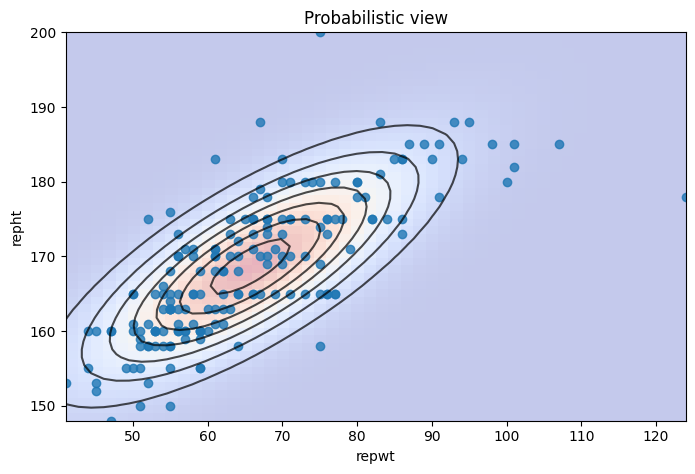

In [256]:
fig = plt.figure(figsize=(8,8))
ax = fig.gca()
ax.imshow(np.rot90(Z), cmap='coolwarm', extent=[min_length,max_length, min_width,max_width], alpha=0.3)
cset = ax.contour(x, y, Z, colors='k', alpha=0.7)
plt.scatter(davis_df_new.values[:,0],davis_df_new.values[:,1],alpha=0.8)
ax.set_xlabel('repwt')
ax.set_ylabel('repht')
plt.title('Probabilistic view')

We will normalize the magnitude of each column in the data (davis_df_new) to 1 and use the new dataframe davis_df_new_col_norm.

In [257]:
davis_df_new_col_norm = normalize(davis_df_new, axis=0, norm='l2')

In [258]:
davis_df_new_col_norm[1:10,:]

array([[0.05648398, 0.06996539],
       [0.05980657, 0.06952536],
       [0.07752703, 0.07700594],
       [0.06534421, 0.06820526],
       [0.08417221, 0.0726056 ],
       [0.08527974, 0.0726056 ],
       [0.08084962, 0.07920611],
       [0.07863456, 0.07700594],
       [0.07088186, 0.07480577]])

<span style="color:red">**Question 3f:** </span> Show the Probabilistic view of the data davis_df_new_col_norm.

In [259]:
from scipy.stats import multivariate_normal

# davis_df_new_col_norm into dataframe
davis_df_new_col_norm = pd.DataFrame(davis_df_new_col_norm, columns=['repwt','repht'])

# Calculate mean
mu = np.mean(davis_df_new_col_norm.values,0)
Sigma = np.cov(davis_df_new_col_norm.values.transpose())

min_length = np.min(davis_df_new_col_norm.values[:,0]);
min_width = np.min(davis_df_new_col_norm.values[:,1]);
max_length = np.max(davis_df_new_col_norm.values[:,0]);
max_width = np.max(davis_df_new_col_norm.values[:,1]);
x, y = np.mgrid[min_length:max_length:50j, min_width:max_width:50j]

positions = np.empty(x.shape + (2,))
positions[:, :, 0] = x;
positions[:, :, 1] = y

F = multivariate_normal(mu, Sigma)
Z = F.pdf(positions)


Text(0.5, 1.0, 'Probabilistic view')

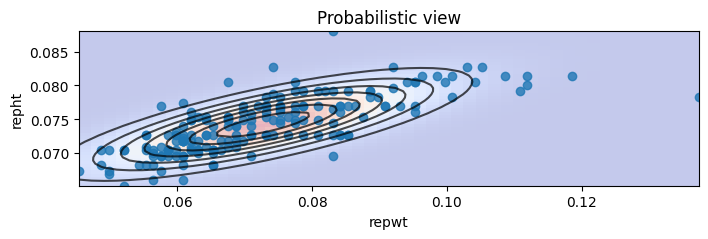

In [260]:
fig = plt.figure(figsize=(8,8))
ax = fig.gca()
ax.imshow(np.rot90(Z), cmap='coolwarm', extent=[min_length,max_length, min_width,max_width], alpha=0.3)
cset = ax.contour(x, y, Z, colors='k', alpha=0.7)
plt.scatter(davis_df_new_col_norm.values[:,0],davis_df_new_col_norm.values[:,1],alpha=0.8)
ax.set_xlabel('repwt')
ax.set_ylabel('repht')
plt.title('Probabilistic view')

<span style="color:red">**Question 3g:** </span> Compare the shape of the covariance structure in Question 3f with that of Question 3e and comment if column normalization has affected the shape of the covariance structure.

<span style="color:green">Answer:</span> Column normalization mainly changes the scale of the covariance (shrinks/rescales the ellipse), but the overall shape/orientation stays similar because the positive relationship between repwt and repht remains.

### 4. Understanding the (in)dependencies among attributes using Covariance matrix

Use 'Davis' data. Do not include Unnamed attribute in this analysis.

<span style="color:red">**Question 4a:** </span> Compute the covariance matrix.

In [245]:
davis_df.head()

,sex,weight,height,repwt,repht
0,M,77,182,77.0,180.0
1,F,58,161,51.0,159.0
2,F,53,161,54.0,158.0
3,M,68,177,70.0,175.0
4,F,59,157,59.0,155.0


In [246]:
davis_df_numericals = davis_df.drop(columns=['sex'])

In [247]:
print('Covariance Matrix:')
davis_df_numericals.cov()

Covariance Matrix:


,weight,height,repwt,repht
weight,235.346041,29.136065,177.292357,91.004665
height,29.136065,151.587047,102.833180,85.497729
repwt,177.292357,102.833180,191.385635,99.017403
repht,91.004665,85.497729,99.017403,88.259791


<span style="color:red">**Question 4b:** </span> Which pairs of attributes co-vary in the opposite direction?

<span style="color:green">Answer: </span> None — there are no attribute pairs with negative covariance (opposite direction).



<span style="color:red">**Question 4c:** </span> Compute the correlation matrix.

In [248]:
print('Correlation Matrix:')
davis_df_numericals.corr()

Correlation Matrix:


,weight,height,repwt,repht
weight,1.000000,0.154258,0.835376,0.631435
height,0.154258,1.000000,0.603737,0.739166
repwt,0.835376,0.603737,1.000000,0.761860
repht,0.631435,0.739166,0.761860,1.000000


<span style="color:red">**Question 4d:** </span> Which pairs of attributes are highly correlated? Clearly specify the highly positive and highly negatively correlated attributes.

<span style="color:green">Answer: </span>
Highly positively correlated:

  * weight ↔ repwt (0.835)
  * repwt ↔ repht (0.762)
  * height ↔ repht (0.739)

Highly negatively correlated:

  * None



<span style="color:red">**Question 4e:** </span> Which pairs of attributes are uncorrelated?

<span style="color:green">Answer:</span> None (no correlation is close to 0).

Most nearly uncorrelated (weakest correlation): weight ↔ height (0.154).

<span style="color:red">**Question 4f:** </span> What information did you gather from a correlation matrix that is not available in a covariance matrix?

<span style="color:green">Answer:</span> From the correlation matrix, I can directly compare the strength and direction of relationships (−1 to +1), which isn’t possible with covariance because it depends on variable scales.

### 5. Dimensionality Reduction: Feature Selection

**Data:** Iris dataset from the practice notebook. (https://raw.githubusercontent.com/plotly/datasets/master/iris.csv)

**Assumption:** Assume that your goal is to cluster the data to identify the species 'Name'. Clustering algorithm takes as input data points and attributes. It groups points that are similar to each other into a separate cluster. It puts points that are dissimilar in different cluster. Note that the 'Name' attribute will be hidden from the clustering algorithm.

In [261]:
import seaborn as sns
iris_df = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/iris.csv')

In [262]:
iris_df.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


<span style="color:red">**Question 5a:** </span> If you are allowed to select only one attribute, which attribute would be highly useful for the clustering task. Provide a reason. Use pairplot to answer this question.

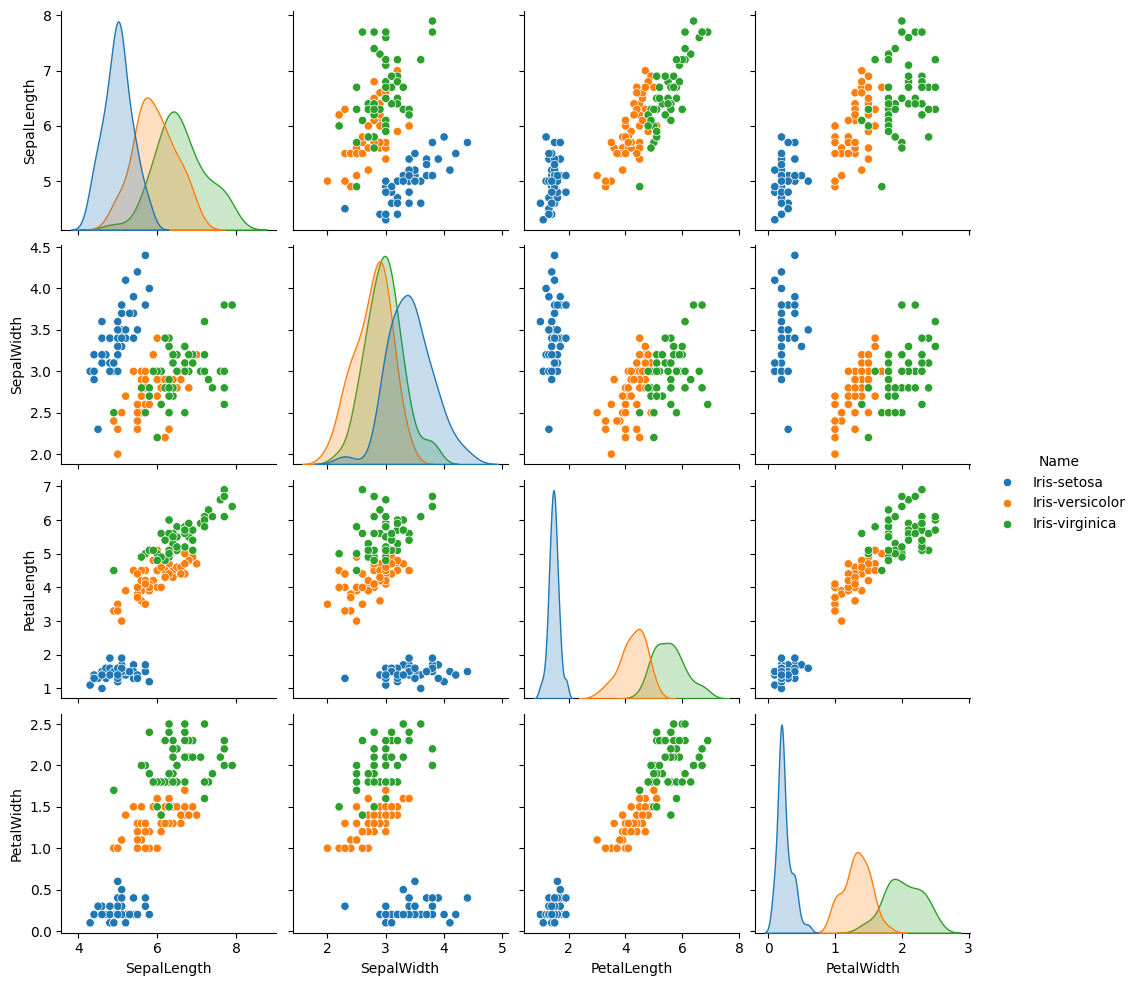

In [263]:
sns.pairplot(iris_df, hue="Name")

<span style="color:green">Answer:</span> I would choose PetalLength. From the pairplot, PetalLength shows the clearest separation among the species, with Iris-setosa forming a completely distinct cluster and less overlap between the other two species compared to the sepal features. This makes it highly effective for clustering. PetalWidth is also informative, but PetalLength shows slightly clearer separation across all species.

<span style="color:red">**Question 5b:** </span> If you are allowed to select only two features, which feature would be highly useful for the clustering task. Provide a reason. Use pairplot to answer this question.

<span style="color:green">Answer:</span> If I am allowed to select only two features, I would choose PetalLength and PetalWidth.

From the pairplot, this feature pair shows the clearest separation of clusters: Iris-setosa is completely separated, and Iris-versicolor and Iris-virginica show much less overlap compared to sepal-based features. This makes PetalLength and PetalWidth the most effective pair for clustering.

<span style="color:red">**Question 5c:** </span>In real-world problems ground-truth (types of iris plants) will not be available to select the features, how do you perform **feature selection** in that case?

<span style="color:green">Answer:</span> In real-world problems where ground-truth labels are not available, I would perform feature selection process. I would select features based on their statistical and structural properties, such as variance, correlation, and how well they separate clusters.

For example, I can:

- Remove features with low variance since they do not contribute much information.

- Remove highly correlated features to avoid redundancy.

### 6. Dimensionality Reduction: PCA on Iris Data

<span style="color:red">**Question 6a:** </span> Perform PCA on Iris dataset and project the data onto the first two principal components. Use the attributes 'SepalLength','SepalWidth','PetalLength', and 'PetalWidth'.

Hint: Use iris_df[['SepalLength','SepalWidth','PetalLength','PetalWidth']] to use the specified attributes.

In [264]:
iris_df_numericals = iris_df[['SepalLength','SepalWidth','PetalLength','PetalWidth']]
iris_df_numericals.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


<Axes: >

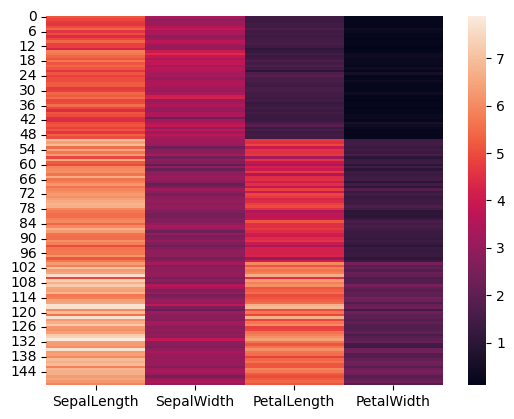

In [265]:
sns.heatmap(iris_df_numericals)

In [266]:
pca = PCA(2)  # project from 4 to 2 dimensions
projected = pca.fit_transform(iris_df_numericals)
print(iris_df_numericals.shape)
print(projected.shape)

(150, 4)
(150, 2)


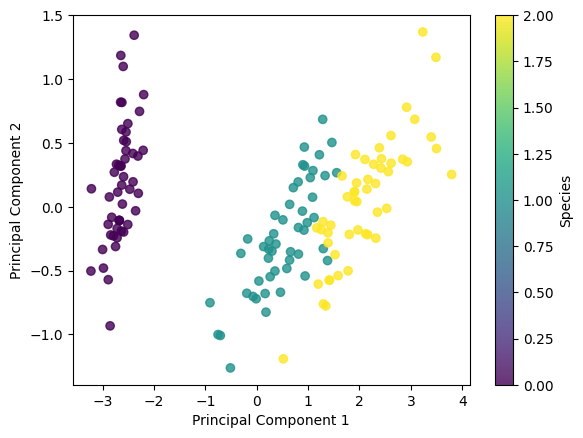

In [267]:
species = iris_df['Name'].astype('category').cat.codes

# Plot
plt.scatter(projected[:, 0], projected[:, 1],
            c=species, cmap='viridis', alpha=0.8)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Species')
plt.show()

<span style="color:red">**Question 6b:** </span> Generate a pairplot (along with colors for the different types of iris plants) between the two newly generated features using PCA in the above step.

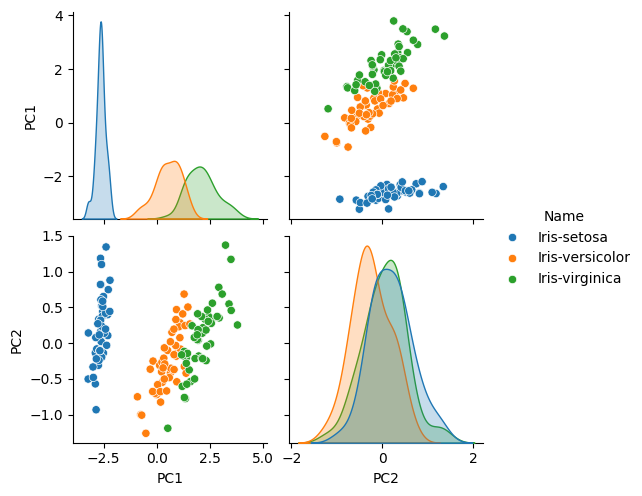

In [268]:
projected_df = pd.DataFrame(
    projected,
    columns=["PC1", "PC2"]
)

projected_df["Name"] = iris_df['Name']

sns.pairplot(projected_df, hue="Name")

<span style="color:red">**Question 6c:** </span> From the above pairplot, if only one newly generated attribute were to be used for clustering the data which newly generated attribute is best suited. Provide a reason. Is the newly generated attribute better than the feature selected in Question 5a?

<span style="color:green">Answer:</span> PC1 is the best newly generated attribute for clustering because it shows the clearest separation of the iris species with minimal overlap in the pairplot.

Yes, PC1 is better than PetalLength (from Question 5a) because it captures the maximum variance from all features, leading to improved cluster separation.

<span style="color:red">**Question 6d:** </span> From the above pairplot, if two newly generated attributes were to be used for clustering the data, are the two newly generated attributes better than the features selected in Question 5b?

<span style="color:green">Answer:</span> Yes. PC1 and PC2 are better than PetalLength and PetalWidth because together they capture most of the data variance and show clearer, more compact cluster separation in the pairplot, especially for Iris-setosa and improved separation of the other two species.

<span style="color:red">**Question 6e:** </span> In general, are principal components guaranteed to be more informative than the original features for the data mining task at hand?

<span style="color:green">Answer:</span> No. Principal components maximize variance, not task relevance, so they are not guaranteed to be more informative than the original features for a specific data mining task.

<span style="color:red">**Question 6f:** </span>In real-world problems ground-truth (types of iris plants) will not be available to determine if the principal compoents or original features are better suited for the data mining task at hand. How should one proceed with the data mining task?

<span style="color:green">Answer:</span> When ground-truth labels are not available, I would rely on visual inspection, variance analysis, and dimensionality reduction methods like PCA to understand the structure of the data. I would then choose the representation that shows clearer patterns and separation for the data mining task.

### 7. Dimensionality Reduction: PCA on synthetic datasets

Consider the following synthetic dataset we refer to as **Blobs**. This dataset has 500 data points centered around (-5, -5), (0,0) and (5,5). This dataset has 1500 data points and 2 attributes.

In [269]:
n_samples = 1500
random_state = 42
centers = [(-5, -5), (0, 0), (5, 5)]
Blobs_X, Blobs_y = datasets.make_blobs(n_samples=n_samples,centers=centers,random_state=random_state)

In [270]:
Blobs_X.shape

(1500, 2)

Text(0.5, 1.0, 'Blobs')

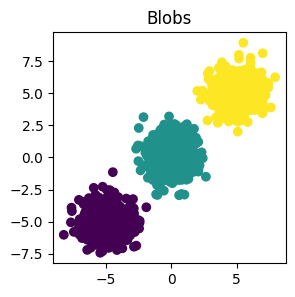

In [271]:
plt.figure(figsize=(3,3))
plt.scatter(Blobs_X[:, 0], Blobs_X[:, 1], c= Blobs_y)
plt.title('Blobs')


We generated a new dataset **Blobs1** by adding an extra attribute to this 2D Blobs dataset. The values for this new attribute are drawn from a normal distribution with mean 0 and variance 1.

In [272]:
Blobs1= pd.DataFrame(Blobs_X)
Blobs1['2'] = np.random.randn(1500)
Blobs1.head()

,0,1,2
0,0.168461,1.317598,-1.320679
1,-3.534351,-5.225776,-0.178492
2,-6.525525,-5.691908,-0.236907
3,-0.120948,0.419532,1.044769
4,-5.469474,-4.457440,0.866531


We generated a new dataset **Blobs2** by adding an extra attribute to the 2D Blobs dataset. The values for this new attribute are drawn from a normal distribution with mean 0 and variance 100. Read more about how to do this at https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.random.randn.html.

In [273]:
Blobs2= pd.DataFrame(Blobs_X)
Blobs2['2'] = np.random.randn(1500)*10
Blobs2.head()

,0,1,2
0,0.168461,1.317598,8.376507
1,-3.534351,-5.225776,13.559940
2,-6.525525,-5.691908,-13.981422
3,-0.120948,0.419532,-6.711725
4,-5.469474,-4.457440,-4.755384


We generated a new dataset **Blobs3** by adding two extra attributes to the 2D Blobs dataset. The values for the two new attributes are drawn from a normal distribution with mean 0 and variance 100.

In [274]:
Blobs3= pd.DataFrame(Blobs_X)
Blobs3['2'] = np.random.randn(1500)*10
Blobs3['3'] = np.random.randn(1500)*10
Blobs3.head()

,0,1,2,3
0,0.168461,1.317598,18.084870,6.154929
1,-3.534351,-5.225776,-14.468208,-18.871478
2,-6.525525,-5.691908,-11.843906,-9.845903
3,-0.120948,0.419532,-3.703282,0.759732
4,-5.469474,-4.457440,-3.065182,15.340254


<span style="color:red">**Question 7a:** </span> Plot pairplot for **Blobs1** data. By visually examining this plot, comment on the variance of the third attribute in comparison to the first two attributes.

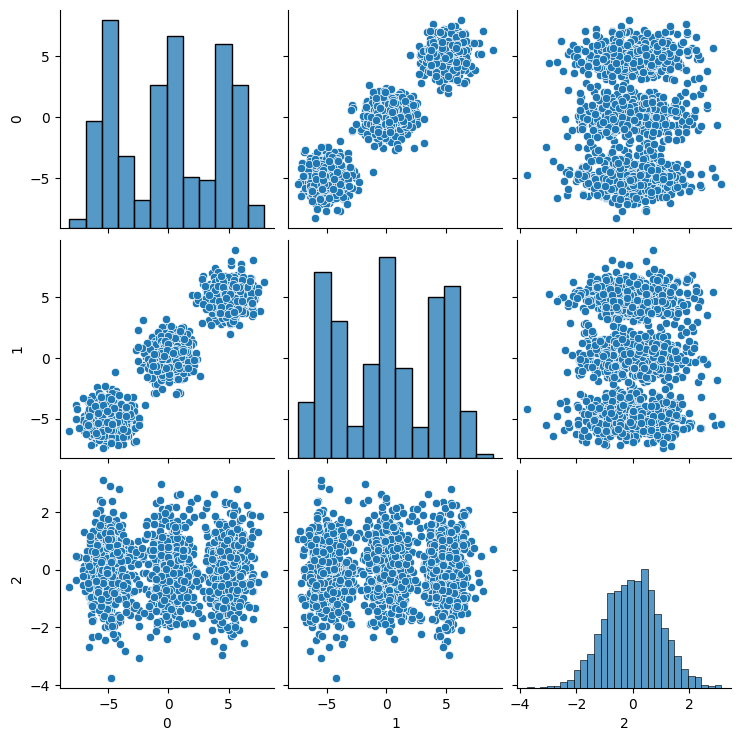

In [275]:
sns.pairplot(Blobs1)

<span style="color:green">Answer:</span> From the pairplot of Blobs1, the third attribute has much lower variance compared to the first two attributes.
On the diagonal, the third attribute follows a single normal distribution, while the first and second attributes show three peaks, corresponding to the three blob centers.
In the off-diagonal plots, the clusters remain separated due to attributes 0 and 1, while the third attribute behaves like random noise and does not improve separation.

<span style="color:red">**Question 7b:** </span> Perform PCA on **Blobs1** data. Project data onto the first two principal components. Generate a pairplot for the newly constructed attributes.

In [276]:
pca = PCA(2)  # project from 3 to 2 dimensions
projected_Blobs1 = pca.fit_transform(Blobs1.values)
print(Blobs1.shape)
print(projected_Blobs1.shape)

(1500, 3)
(1500, 2)


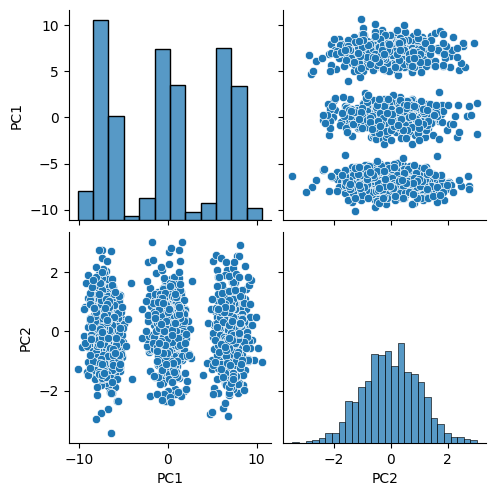

In [277]:
projected_Blobs1_df = pd.DataFrame(
    projected_Blobs1,
    columns=["PC1", "PC2"]
)
sns.pairplot(projected_Blobs1_df)

<span style="color:red">**Question 7c:** </span> By comparing the distributions for the newly generated attributes in Question 7b with the previous pairplot in Question 7a, determine which attribute is captured by the first principal component and which attribute is captured by the second principal component. Provide a reason for your observations.

<span style="color:green">Answer:</span> PC1 captures the information from the first two original attributes, since it shows a three-peak distribution corresponding to the blob clusters.
PC2 captures the third attribute, as it has a single Gaussian distribution similar to the added noise feature.


<span style="color:red">**Question 7d:** </span> Plot pairplot for **Blobs2** data. By visually examining this plot, comment on the variance of the third attribute in comparison to the first two attributes.

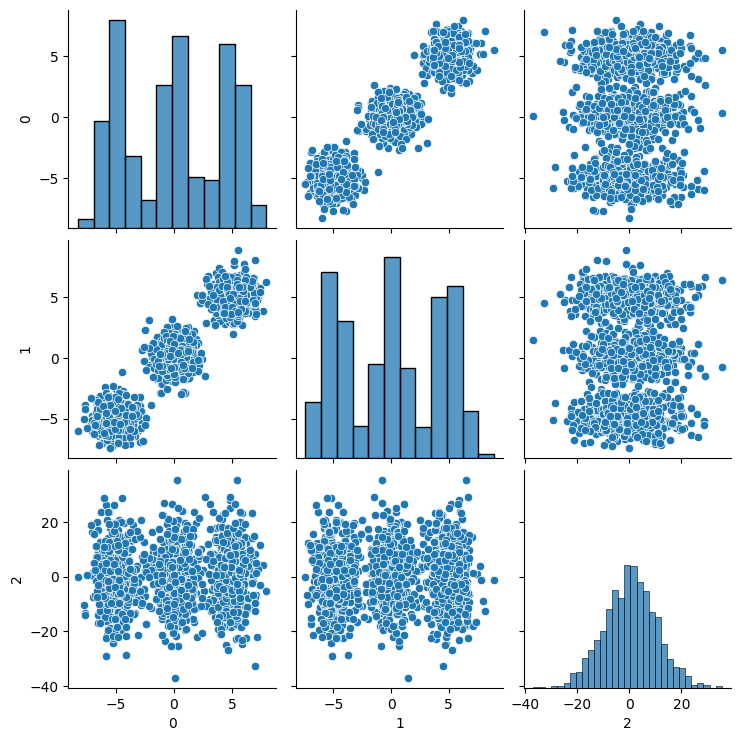

In [278]:
sns.pairplot(Blobs2)

<span style="color:green">Answer:</span> From the pairplot of Blobs2, the third attribute has much higher variance than the first two attributes.
This is evident from the diagonal plot, where the third attribute shows a much wider spread, and from the off-diagonal plots, where the large variance of the third attribute dominates the scale while not contributing to clear cluster separation.

<span style="color:red">**Question 7e:** </span> Perform PCA on **Blobs2** data. Project data onto the first two principal components. Generate a pairplot for the newly constructed attributes.

In [279]:
pca = PCA(2)  # project from 3 to 2 dimensions
projected_Blobs2 = pca.fit_transform(Blobs2.values)
print(Blobs2.shape)
print(projected_Blobs2.shape)

(1500, 3)
(1500, 2)


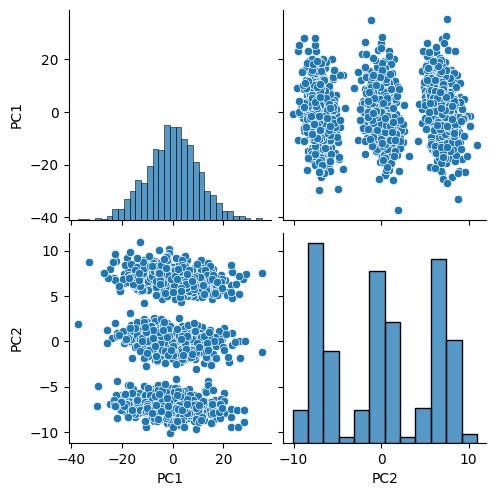

In [280]:
projected_Blobs2_df = pd.DataFrame(
    projected_Blobs2,
    columns=["PC1", "PC2"]
)
sns.pairplot(projected_Blobs2_df)

<span style="color:red">**Question 7f:** </span> By comparing the distributions for the newly generated attributes in Question 7e with the previous pairplot in Question 7d, determine which attribute is captured by the first principal component and which attribute is captured by the second principal component. Why would have caused this (in comparison to your observation in Question 7c)?

<span style="color:green">Answer:</span> PC1 captures the third attribute added in Blobs2 because it has the largest variance, which dominates the first principal component.
PC2 captures the original blob structure from the first two attributes, as seen by the three separated groups in its distribution.
This happens because PCA prioritizes directions of maximum variance, even if that variance comes from noise.

<span style="color:red">**Question 7g:** </span> Are the three blobs separately visible after projection based on PCA in Question 7e?

<span style="color:green">Answer:</span> Yes. The three blobs are still separately visible after PCA projection because PC2 preserves the original clustering structure, showing three distinct groups, even though PC1 is dominated by the high-variance noise attribute.

<span style="color:red">**Question 7h:** </span> Plot pairplot for **Blobs3** data. By visually examining this plot, comment on the strength of the correlation between the first two attributes. Also, comment on the strength of the correlation between the second two attributes.

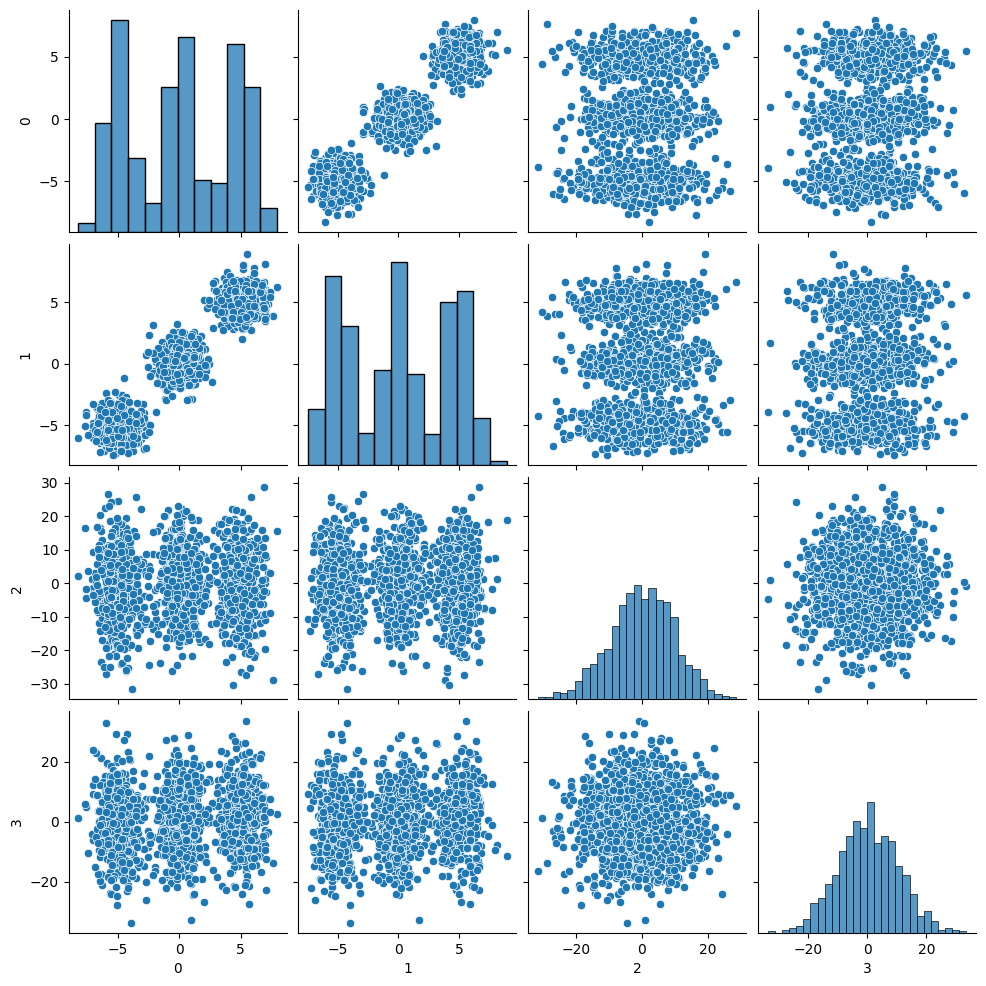

In [281]:
sns.pairplot(Blobs3)

<span style="color:green">Answer:</span> From the pairplot of Blobs3:

The first two attributes (0 and 1) show a strong positive correlation.
This is evident from the clear diagonal alignment of points and the visible cluster structure across these two attributes.

The second two attributes (2 and 3) show little to no correlation.
Their scatter plot appears roughly circular with no clear linear trend, and the diagonal plots show independent Gaussian distributions.

This indicates that attributes 0 and 1 are strongly correlated, while attributes 2 and 3 are largely independent.

<span style="color:red">**Question 7i:** </span> Perform PCA on **Blobs3** data. Project data onto the first two principal components. Generate a pairplot for the newly constructed attributes.

In [282]:
pca = PCA(2)  # project from 4 to 2 dimensions
projected_Blobs3 = pca.fit_transform(Blobs3.values)
print(Blobs3.shape)
print(projected_Blobs3.shape)

(1500, 4)
(1500, 2)


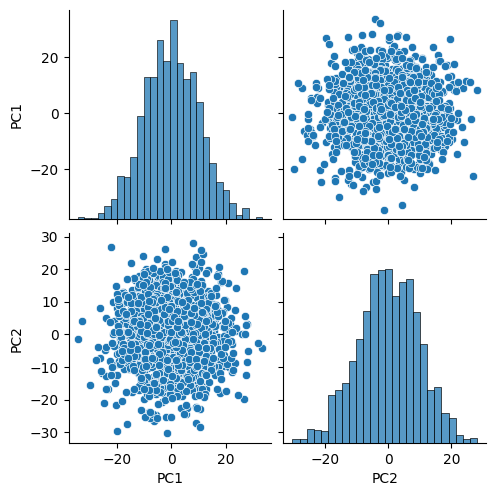

In [283]:
projected_Blobs3_df = pd.DataFrame(
    projected_Blobs3,
    columns=["PC1", "PC2"]
)
sns.pairplot(projected_Blobs3_df)

<span style="color:red">**Question 7j:** </span>  By comparing the distributions for the newly generated attributes in Question 7i with the previous pairplot in Question 7h, determine which attribute is captured by the first principal component and which attribute is captured by the second principal component. Why would have caused this (in comparison to your observation in Question 7f and 7c)?

<span style="color:green">Answer:</span> PC1 and PC2 are dominated by the two high-variance noise attributes (attributes 2 and 3) rather than the original blob features.
This happens because both added attributes have large variance, which overwhelms the original structure—unlike in Questions 7c and 7f, where fewer or lower-variance noise features allowed PCA to still capture the blobs.

<span style="color:red">**Question 7k:** </span>  Are the three blobs separately visible after projection based on PCA in Question 7i? What would have caused this, in comparison to your observation in Question 7g?

<span style="color:green">Answer:</span> No, the three blobs are not separately visible after PCA in Question 7i.
This is because the two high-variance noise attributes dominate PC1 and PC2, causing PCA to ignore the original blob structure. In contrast, in Question 7g only one noise attribute was present, allowing one principal component to still preserve the cluster separation.

<span style="color:red">**Question 7l:** </span>  What limitation of PCA do your observations in Questions 7j, 7f, and 7c highlight?

<span style="color:green">Answer:</span> These observations highlight a key limitation of PCA: PCA is variance-driven, not task-driven.
PCA prioritizes directions with the largest variance, so high-variance noise features can dominate the principal components, even if they are irrelevant to the underlying structure or clustering task.

### 8. Singular Value Decomposition

<span style="color:green"> **(Optional)** </span> <span style="color:red">Question 8a: </span> Using the code provided in the practice notebook for computing PCA, write your own SVD function (U,S,V = mysvd(A)) to factorize the matrix A into U,S, and V.

In [284]:
def mysvd(A, full_matrices=False, eps=1e-12):
    A = np.array(A, dtype=float)
    m, n = A.shape
    r = min(m, n)

    ATA = A.T @ A
    eigvals, V = np.linalg.eigh(ATA)

    idx = np.argsort(eigvals)[::-1]
    eigvals = np.clip(eigvals[idx], 0.0, None)
    V = V[:, idx]

    s = np.sqrt(eigvals)
    V_r = V[:, :r]
    s_r = s[:r]

    U_r = np.zeros((m, r))
    for i in range(r):
        if s_r[i] > eps:
            U_r[:, i] = (A @ V_r[:, i]) / s_r[i]

    S_r = np.diag(s_r)

    # NOTE: V_r is V (n x r). Reconstruction uses V_r.T
    return U_r, S_r, V_r


<span style="color:green"> **(Optional)** </span>  <span style="color:red">Question 8b: </span> Demonstrate that your code is correct by using your function on the following matrix $A$ and showing that the product $USV^T=A$.

In [285]:
A = np.array([
    [1, 1, 1, 0, 0, 0],
    [3, 3, 3, 0, 0, 0],
    [4, 4, 4, 0, 0, 0],
    [5, 5, 5, 0, 0, 0],
    [0, 1, 0, 4, 4, 1],
    [0, 0, 0, 5, 5, 2],
    [0, 0, 0, 2, 2, 2]])

<Axes: >

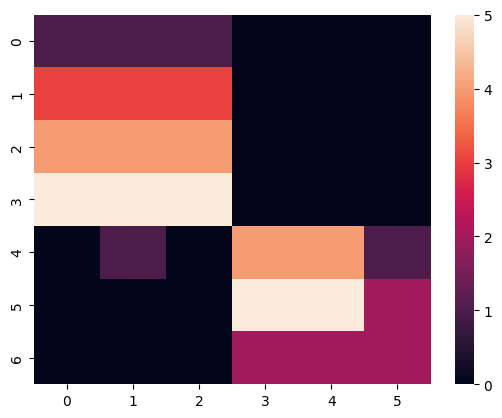

In [286]:
sns.heatmap(A)

A: (7, 6)
U: (7, 6)
S: (6, 6)
V: (6, 6)
A_hat: (7, 6)


<Axes: >

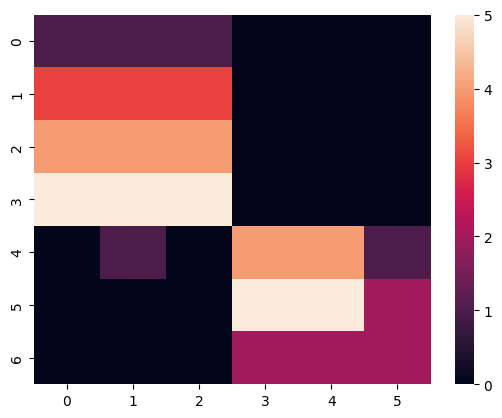

In [287]:
U, S, V = mysvd(A)

print("A:", A.shape)
print("U:", U.shape)
print("S:", np.array(S).shape)
print("V:", V.shape)

A_hat = U @ S @ V.T

print("A_hat:", A_hat.shape)
sns.heatmap(A_hat)

A: (7, 6)
U: (7, 6)
S: (6,)
V: (6, 6)
A_hat: (7, 6)


<Axes: >

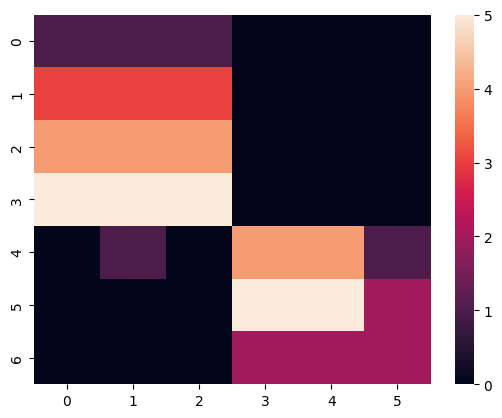

In [288]:
## Test with svd function from scipy
U_scipy, S_scipy, V_scipy = svd(A, full_matrices = False)

print("A:", A.shape)
print("U:", U_scipy.shape)
print("S:", np.array(S_scipy).shape)
print("V:", V_scipy.shape)

A_hat_scipy = U_scipy @ np.diag(S_scipy) @ V_scipy

print("A_hat:", A_hat_scipy.shape)
sns.heatmap(A_hat_scipy)

<span style="color:red">**Question 8c:**</span> Perform SVD on iris dataset and visualize the proportion of variance captured by each spectral value. List the dimensions that captures less than 10% of the total variance.

In [289]:
import pandas as pd
iris_df = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/iris.csv')


In [290]:
data = iris_df.values[:,0:4]
data = data.astype(float) #converts data format from object to numeric

In [291]:
U, S, V = svd(data, full_matrices=False)

In [292]:
S

array([95.95066751, 17.72295328,  3.46929666,  1.87891236])

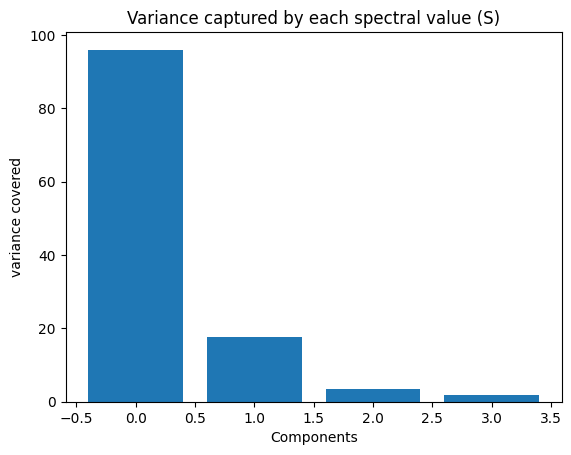

In [293]:
# "Variance" captured
plt.bar(np.arange(len(S)), S)
plt.xlabel('Components')
plt.ylabel('variance covered')
plt.title('Variance captured by each spectral value (S)')
plt.show()

<span style="color:green">Answer:</span> From the variance plots, most variance is captured by the first two spectral values.
The third and fourth components each capture less than 10% of the total variance.
Therefore, the dimensions that capture less than 10% of the variance are components 3 and 4.

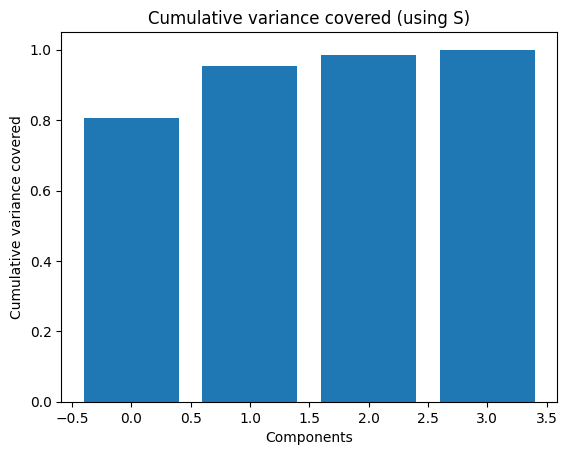

In [294]:
# Cumulative fraction captured
frac = S / np.sum(S)
cumfrac = np.cumsum(frac)

plt.bar(np.arange(len(S)), cumfrac)
plt.xlabel('Components')
plt.ylabel('Cumulative variance covered')
plt.title('Cumulative variance covered (using S)')
plt.show()

<span style="color:red">**Question 8d:**</span> The heatmap of the full data is shown below. Plot all the four spectral decomposition matrices based on SVD.

<Axes: >

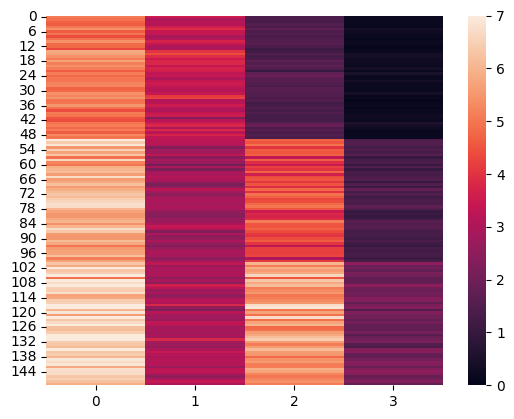

In [295]:
sns.heatmap(data,vmin=0, vmax=7)

<Axes: >

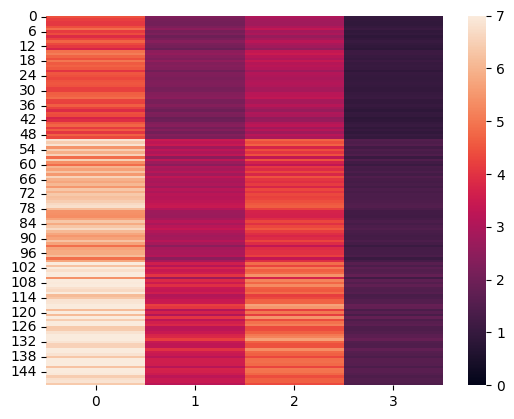

In [296]:
sns.heatmap(S[0]*np.outer(U[:,0],V[0,:]), vmin=0, vmax=7)

<Axes: >

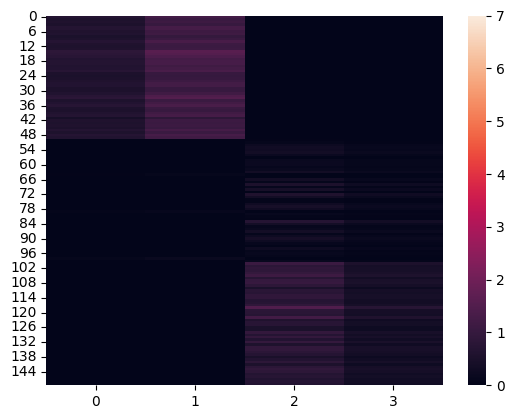

In [297]:
sns.heatmap(S[1]*np.outer(U[:,1],V[1,:]), vmin=0, vmax=7)

<Axes: >

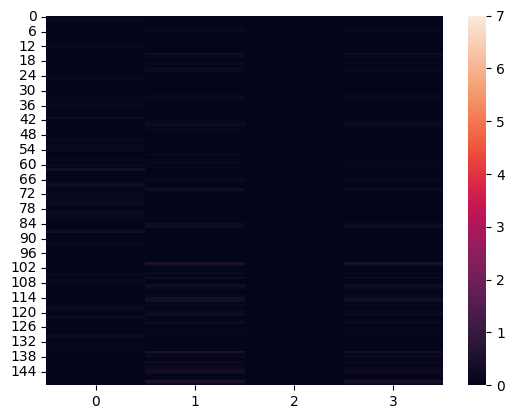

In [298]:
sns.heatmap(S[2]*np.outer(U[:,2],V[2,:]), vmin=0, vmax=7)

<Axes: >

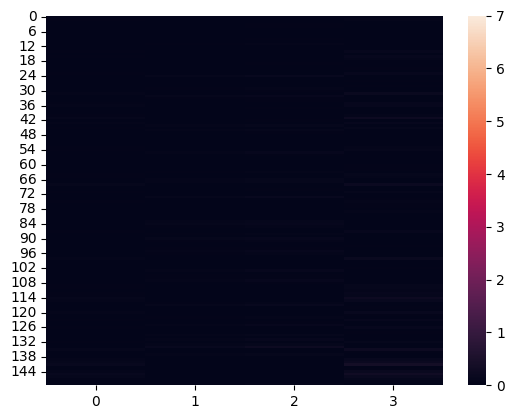

In [299]:
sns.heatmap(S[3]*np.outer(U[:,3],V[3,:]), vmin=0, vmax=7)

<span style="color:red">**Question 8e:**</span> Visually examine the magnitude of values present in each of the four spectral decomposition matrices and comment on which two of the four matrices have elements with relatively small magnitude in them. Provide a reason for this based on your obsevation in Question 8c.

<span style="color:green">Answer:</span> The third and fourth spectral decomposition matrices have elements with relatively small magnitudes.
This is because, as observed in Question 8c, the third and fourth spectral values capture less than 10% of the total variance, so their corresponding rank-1 components contribute very little to the overall data representation.

### 9. Linear Discriminant Analysis

We will use digits data for studying the use of LDA.

In [300]:
digits = load_digits()

The data with 1797 samples and 64 attributes is in the object digits.data. These 64 attributes represent pixels in an 8x8 image.

In [301]:
digits.data.shape

(1797, 64)

The 1797 images are digits from 0...9. This information is in the digits.target variable.

In [302]:
digits.target

array([0, 1, 2, ..., 8, 9, 8])

For this part, we will only focus on digits 3 and 8. To this end, we generate indices of 183 samples with 3s and indices of 174 samples with 8s.

In [303]:
Threes = np.where(digits.target==3)
Eights = np.where(digits.target==8)
[np.size(Threes), np.size(Eights)]

[183, 174]

We will take samples from these indices and construct a matrix X such that the first 183 samples represent 3s and the remaining ones represent 8s. The variable y captures this information.

In [304]:
indices = np.hstack((Threes[0], Eights[0]));
X = digits.data[indices,:]
y = np.hstack((3*np.ones(np.size(Threes)), 8*np.ones(np.size(Eights))))

In [305]:
X

array([[ 0.,  0.,  7., ...,  9.,  0.,  0.],
       [ 0.,  2.,  9., ..., 11.,  0.,  0.],
       [ 0.,  1.,  8., ...,  2.,  0.,  0.],
       ...,
       [ 0.,  0.,  5., ...,  3.,  0.,  0.],
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

In [306]:
X.shape

(357, 64)

In [307]:
y

array([3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
       3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
       3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
       3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
       3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
       3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
       3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
       3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
       3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
       3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
       3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 8., 8., 8., 8.,
       8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8.,
       8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8., 8.,
       8., 8., 8., 8., 8.

In [308]:
y.shape

(357,)

<span style="color:red">**Question 9a:**</span> Visually examine the following heatmap of the data X and comment which among attributes 43 and 45 can separate the 3s from 8s better.

[Text(0.5, 80.7222222222222, 'Attributes'),
 Text(220.72222222222223, 0.5, 'Samples')]

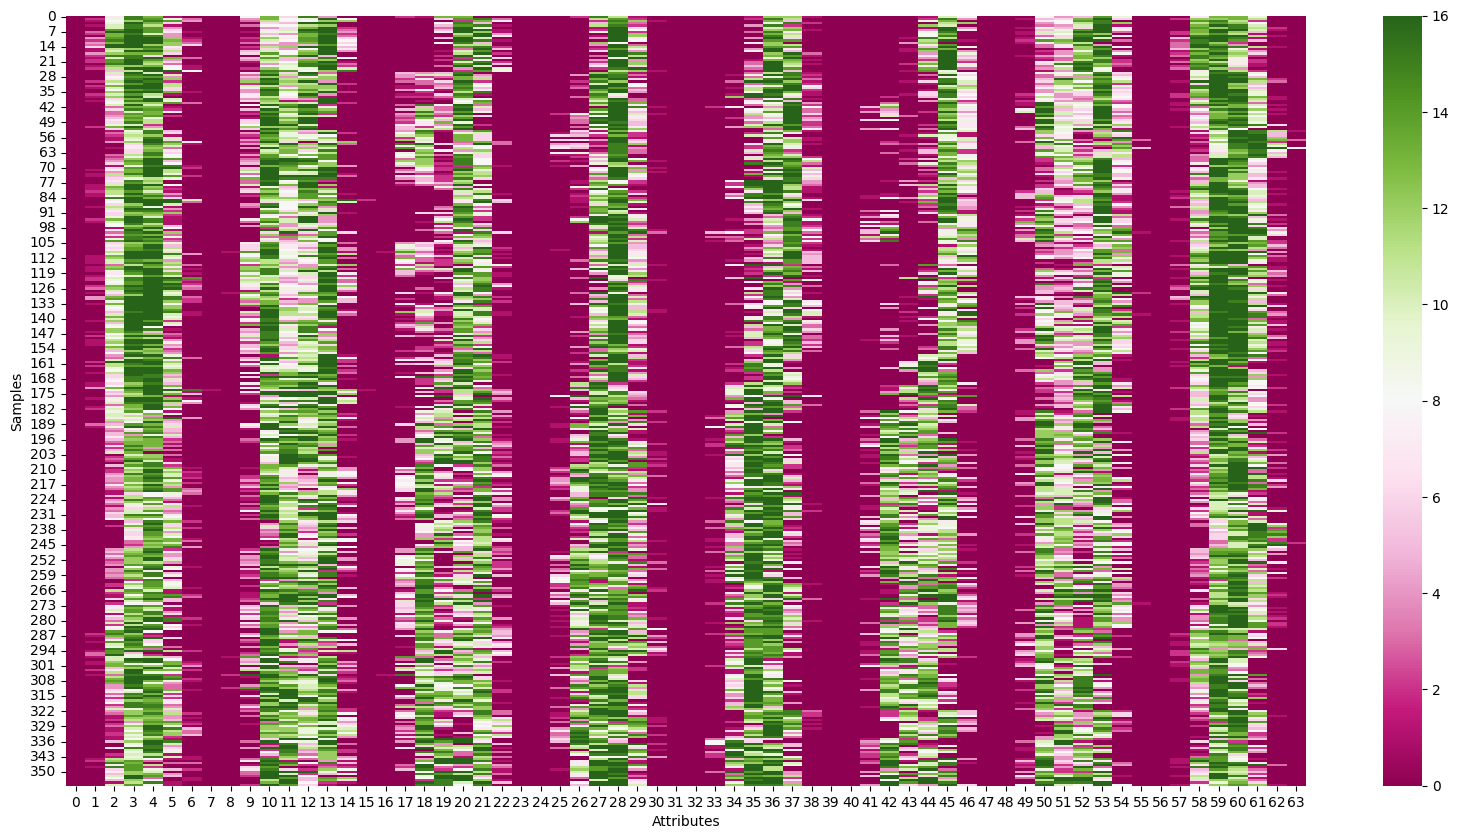

In [309]:
plt.figure(figsize=(20,10))
ax = sns.heatmap(X,cmap='PiYG')
ax.set(xlabel='Attributes', ylabel='Samples')


<span style="color:green">Answer:</span> Attribute 43 separates digits 3 and 8 better. In the heatmap, attribute 43 shows a clear split across samples: one group has consistently low values (reddish) and the other high values (greenish), corresponding to the two classes. In contrast, attribute 45 shows mostly similar values across all samples with only minor noise, so it does not provide good class separation.

<span style="color:red">**Question 9b:**</span> Perform LDA on this data. Plot the heatmap of the projected data and comment if the resultant projection is better than the best attribute between 43 and 45.

**Steps involved in performing LDA**
1. Input data: set of points in $R^d$
2. Compute mean vectors $\mu_1$ and $\mu_2$
3. Compute between class scatter matrix $S_B$
4. Compute within class scatter matrix $S_W$
5. Compute the matrix $S_W^{-1}S_B$
4. Compute the first eigenvector ($v_1$) of the matrix $S_W^{-1}S_B$
5. Project data on to this eigenvector $Xv_1$

LinearDiscriminantAnalysis function accomplishes all of this.

In [310]:
lda = LinearDiscriminantAnalysis(n_components=1)
X_r1 = lda.fit(X, y).transform(X)

[Text(0.5, 80.7222222222222, 'Attributes'),
 Text(220.72222222222223, 0.5, 'Samples')]

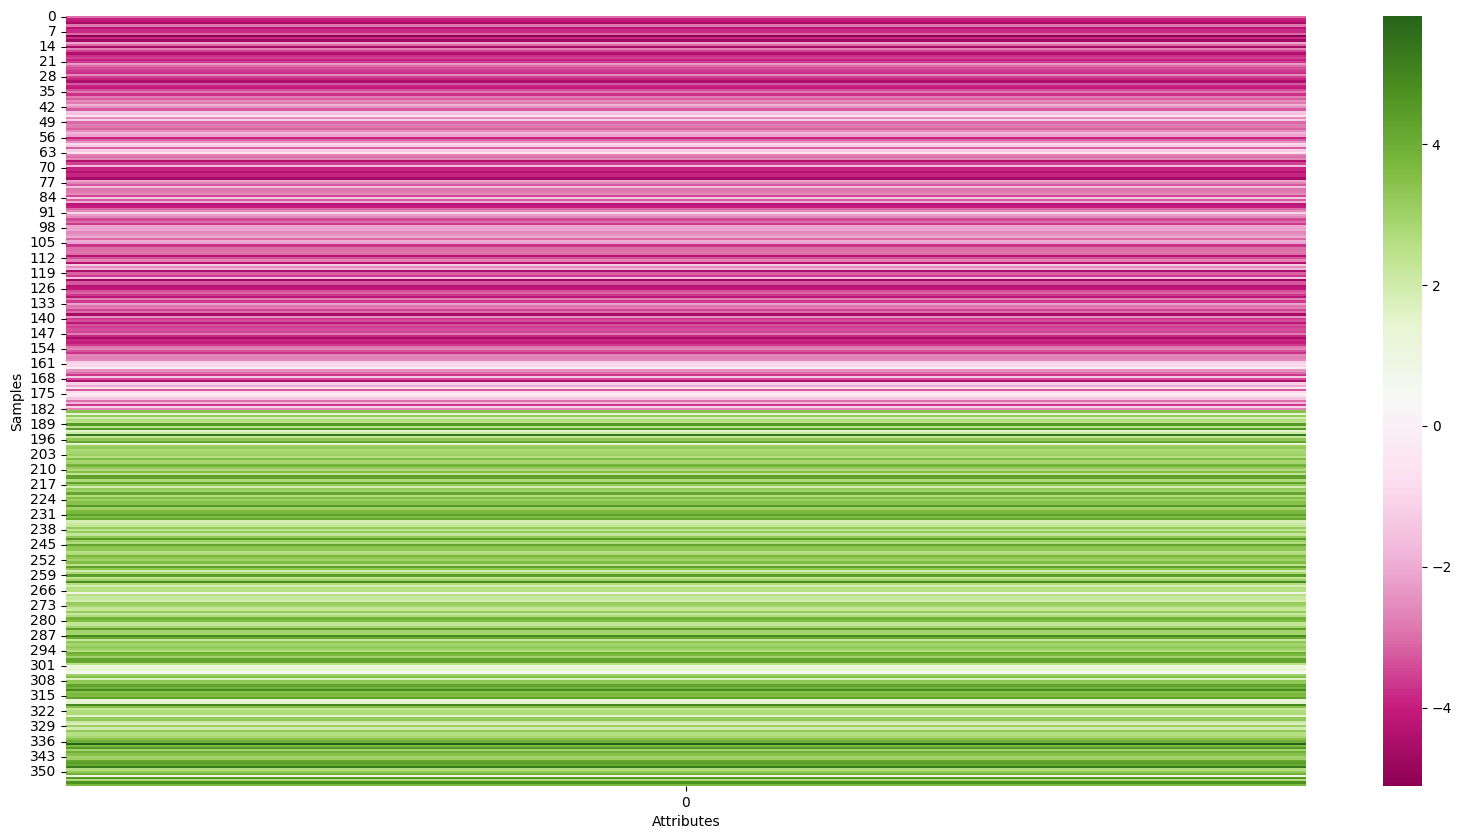

In [311]:
plt.figure(figsize=(20,10))
ax = sns.heatmap(X_r1,cmap='PiYG')
ax.set(xlabel='Attributes', ylabel='Samples')

<span style="color:green">Answer:</span> The LDA projection clearly separates the samples into two distinct blocks corresponding to digits 3 and 8, with minimal overlap. This separation is much stronger than that obtained using any single attribute (such as 43 or 45), since LDA optimally combines all attributes to maximize class separation.



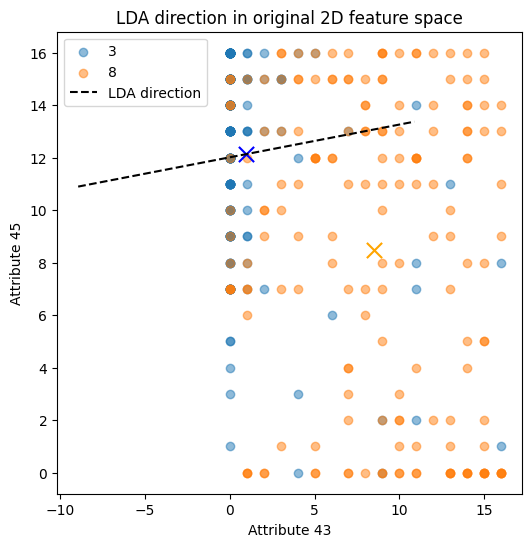

In [312]:
# pick two attributes
i, j = 43, 45
X2 = X[:, [i, j]]

# fit LDA on full data
lda = LinearDiscriminantAnalysis(n_components=1)
lda.fit(X, y)

# class means in original space
m3 = X[y == 3].mean(axis=0)[[i, j]]
m8 = X[y == 8].mean(axis=0)[[i, j]]

# LDA direction (weights for features i and j)
w = lda.coef_[0][[i, j]]
w = w / np.linalg.norm(w)

# plot data
plt.figure(figsize=(6,6))
plt.scatter(X2[y==3,0], X2[y==3,1], alpha=0.5, label='3')
plt.scatter(X2[y==8,0], X2[y==8,1], alpha=0.5, label='8')

# plot class means
plt.scatter(*m3, c='blue', s=120, marker='x')
plt.scatter(*m8, c='orange', s=120, marker='x')

# plot LDA direction
t = np.linspace(-10, 10, 100)
plt.plot(m3[0] + t*w[0], m3[1] + t*w[1], 'k--', label='LDA direction')

plt.xlabel(f'Attribute {i}')
plt.ylabel(f'Attribute {j}')
plt.legend()
plt.title('LDA direction in original 2D feature space')
plt.show()
